In [1]:
from pathlib import Path

# El paquete mountain_car queda instalado con `uv sync`; ejecutar desde la raíz del repo.
ROOT = Path.cwd()

In [2]:
from pathlib import Path

import numpy as np

from mountain_car.agents.qlearning import QLearningAgent

In [3]:
SAVE_PATH = ROOT / "saves" / "qlearning_tuned.pkl"

agent = QLearningAgent("MountainCar-v0", n_bins=24, lr=0.2, epsilon_decay=0.995)
rewards = agent.train(total_episodes=5000, log_interval=500)
agent.save(SAVE_PATH)

Episode 500/5000 | Avg Reward: -200.00 | Epsilon: 0.0816 | States visited: 328
Episode 1000/5000 | Avg Reward: -197.39 | Epsilon: 0.0100 | States visited: 384
Episode 1500/5000 | Avg Reward: -191.48 | Epsilon: 0.0100 | States visited: 410
Episode 2000/5000 | Avg Reward: -189.39 | Epsilon: 0.0100 | States visited: 416
Episode 2500/5000 | Avg Reward: -184.76 | Epsilon: 0.0100 | States visited: 422
Episode 3000/5000 | Avg Reward: -171.54 | Epsilon: 0.0100 | States visited: 422
Episode 3500/5000 | Avg Reward: -166.29 | Epsilon: 0.0100 | States visited: 422
Episode 4000/5000 | Avg Reward: -150.27 | Epsilon: 0.0100 | States visited: 423
Episode 4500/5000 | Avg Reward: -173.37 | Epsilon: 0.0100 | States visited: 424
Episode 5000/5000 | Avg Reward: -146.78 | Epsilon: 0.0100 | States visited: 424
Saved Q-Learning agent to c:\Users\PaolaEspinosaHurtado\OneDrive - Lexsoft Systems, S.L\Personal\Unisabana\Simulacion\mountain_car\src\mountain_car\agents\saves\qlearning_tuned.pkl


In [4]:
print(f"avg_last_500 = {float(np.mean(rewards[-500:])):.3f}")
print(f"avg_last_1000 = {float(np.mean(rewards[-1000:])):.3f}")
print(f"last10 = {rewards[-10:]}")

avg_last_500 = -146.780
avg_last_1000 = -160.076
last10 = [-191.0, -150.0, -159.0, -149.0, -144.0, -148.0, -145.0, -148.0, -150.0, -146.0]


avg_last_500 = -146.780
avg_last_1000 = -160.076
last10 = [-191.0, -150.0, -159.0, -149.0, -144.0, -148.0, -145.0, -148.0, -150.0, -146.0]


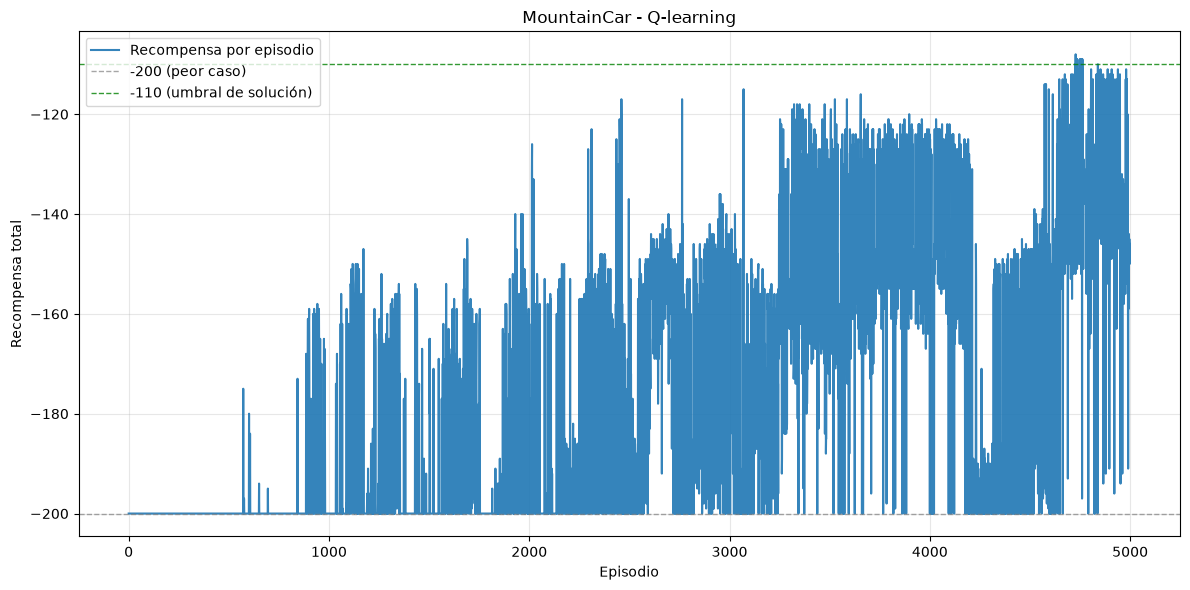

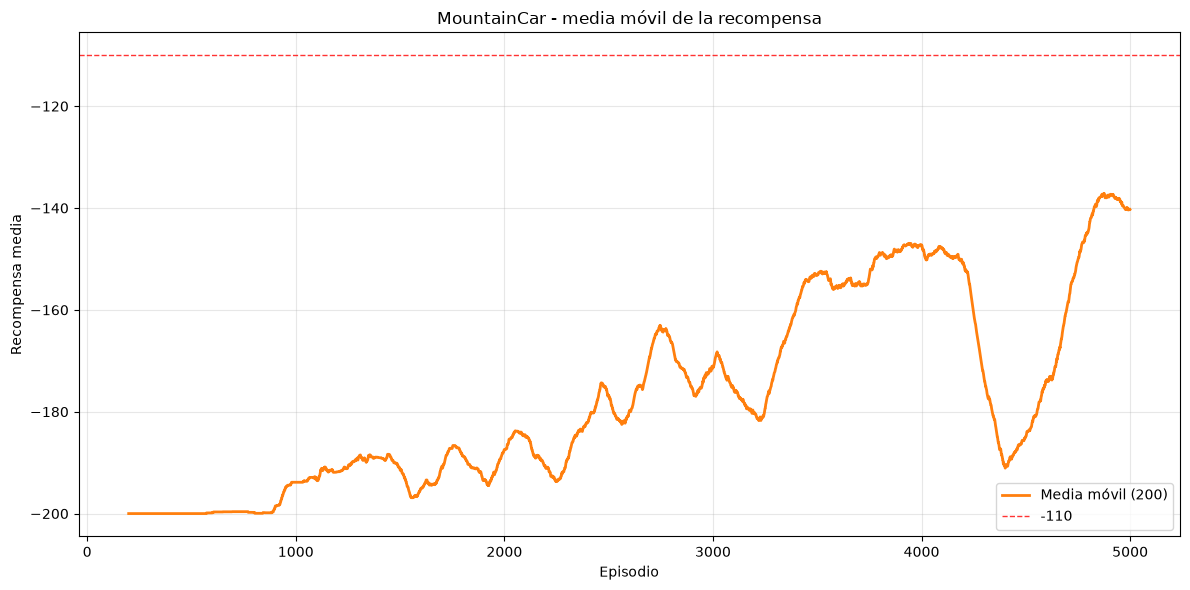

In [5]:
# Gráficas de rendimiento del agente Q-learning
import matplotlib.pyplot as plt
import numpy as np

# Cifras clave para interpretar la evolución
avg_last_500 = float(np.mean(rewards[-500:]))
avg_last_1000 = float(np.mean(rewards[-1000:]))
print(f"avg_last_500 = {avg_last_500:.3f}")
print(f"avg_last_1000 = {avg_last_1000:.3f}")
print(f"last10 = {rewards[-10:]}")

# Curva de recompensa por episodio
plt.figure(figsize=(12, 6))
plt.plot(rewards, color="tab:blue", linewidth=1.5, alpha=0.9, label="Recompensa por episodio")
plt.axhline(-200, color="gray", linestyle="--", linewidth=1, alpha=0.7, label="-200 (peor caso)")
plt.axhline(-110, color="green", linestyle="--", linewidth=1, alpha=0.8, label="-110 (umbral de solución)")
plt.title("MountainCar - Q-learning")
plt.xlabel("Episodio")
plt.ylabel("Recompensa total")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("qlearning_rewards.png", dpi=200)
plt.show()

# Media móvil para ver la tendencia real
d = min(200, len(rewards))
ma = np.convolve(rewards, np.ones(d) / d, mode="valid")
xs = np.arange(d - 1, len(rewards))

plt.figure(figsize=(12, 6))
plt.plot(xs, ma, color="tab:orange", linewidth=2, label=f"Media móvil ({d})")
plt.axhline(-110, color="red", linestyle="--", linewidth=1, alpha=0.8, label="-110")
plt.title("MountainCar - media móvil de la recompensa")
plt.xlabel("Episodio")
plt.ylabel("Recompensa media")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("qlearning_moving_average.png", dpi=200)
plt.show()
